In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

@dataclass(frozen=True)
class Example:
    x: np.ndarray
    target_y: float #for binary classifier, target_y is -1 or 1; for multiclass classifier, target_y is 0,1,.., K-1

@dataclass(frozen=True)
class Parameters:
    weight: np.ndarray
    bias: float | np.ndarray #bias is float for binary classifier, array for multiclass classifier

# training data for binary classifier
def get_training_data():
    return [
        Example(x=np.array([1, 2]), target_y=-1),
        Example(x=np.array([2, 0]), target_y=1),
        Example(x=np.array([0, 0]), target_y=-1)
    ]


In [8]:
def logistics(logit: float) -> float:
    return 1 / (1 + np.exp(-logit))

def compute_loss(example: Example, params: Parameters) -> float:
    logit = float(params.weight @ example.x + params.bias)
    margin = logit * example.target_y
    return -np.log(logistics(margin))

def compute_training_loss(data: list[Example], params: Parameters) -> float:
    losses = [compute_loss(example=example, params=params) for example in data]
    return float(np.mean(losses))

def compute_gradient_loss(example: Example, params: Parameters) -> Parameters:
    logit = float(params.weight @ example.x + params.bias)
    margin = logit * example.target_y
    # d(loss) / d(margin) = -logistics(-margin)
    grad_margin = -logistics(-margin)
    # d(loss) / d(weight) = -logistics(-margin) * x * target_y
    grad_weight = example.target_y * example.x * grad_margin
    # d(loss) / d(bias) = -logistics(-margin) * target_y
    grad_bias = example.target_y * grad_margin
    return Parameters(weight=grad_weight, bias=grad_bias)

def compute_gradient_training_loss(data: list[Example], params: Parameters) -> Parameters:
    gradients = [compute_gradient_loss(example=example, params=params) for example in data]
    # average of the weight gradients in the training data
    mean_weight = np.mean([grad.weight for grad in gradients], axis=0)
    # average of the bias gradients in the training data
    mean_bias = float(np.mean([grad.bias for grad in gradients]))
    return Parameters(weight=mean_weight, bias=mean_bias)
    

def gradient_descend(data: list[Example], learning_rate: float = 1.0, num_steps: int = 100):
    params = Parameters(weight=np.array([0.0, 0.0]), bias=0.0) #initial params
    loss_history = []

    for step in range(num_steps):
        loss = compute_training_loss(data=training_data, params=params)
        print("step:", step, " loss:", loss, " weight:", params.weight, "bias: ", params.bias)
        loss_history.append(loss)

        gradients = compute_gradient_training_loss(data=training_data, params=params)
        params = Parameters(
            weight=params.weight - gradients.weight * learning_rate, 
            bias=params.bias - gradients.bias * learning_rate)
    return params, loss_history


step: 0  loss: 0.6931471805599453  weight: [0. 0.] bias:  0.0
step: 1  loss: 0.5469780676837823  weight: [ 0.16666667 -0.33333333] bias:  -0.16666666666666666
step: 2  loss: 0.45449484230875065  weight: [ 0.35920513 -0.55949575] bias:  -0.2797478770780609
step: 3  loss: 0.38892516463591403  weight: [ 0.53349834 -0.73365567] bias:  -0.3796464497775248
step: 4  loss: 0.3401004745397549  weight: [ 0.68594402 -0.87492802] bias:  -0.4741457542353853
step: 5  loss: 0.30230704335173036  weight: [ 0.82001454 -0.99280655] bias:  -0.5644586158857976
step: 6  loss: 0.27211798260226366  weight: [ 0.93938457 -1.09319339] bias:  -0.6507091285421174
step: 7  loss: 0.24739098453055205  weight: [ 1.04694276 -1.18010521] bias:  -0.7329345719200585
step: 8  loss: 0.2267287531534948  weight: [ 1.14485439 -1.25639634] bias:  -0.8112352330289122
step: 9  loss: 0.20918250022208618  weight: [ 1.23474767 -1.32415391] bias:  -0.8857704377013622
step: 10  loss: 0.19408436202087467  weight: [ 1.31786726 -1.384939

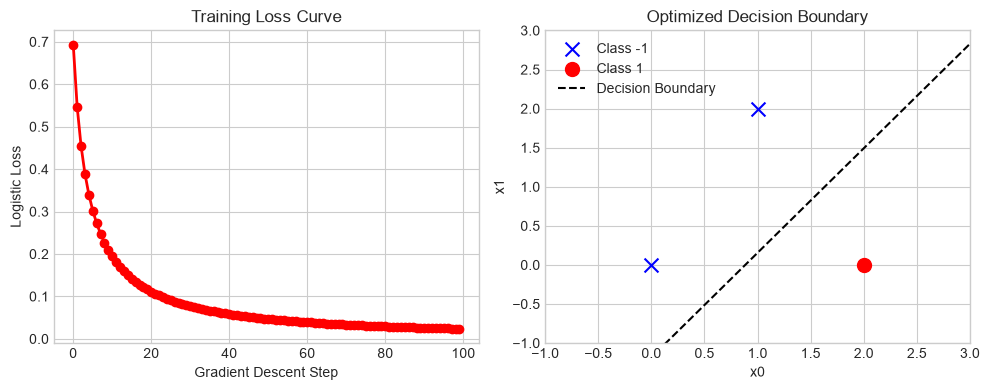

In [10]:
training_data = get_training_data()
params, loss_history = gradient_descend(data=training_data)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(100), loss_history, 'o-r', linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Gradient Descent Step")
plt.ylabel("Logistic Loss")

plt.subplot(1, 2, 2)
for ex in training_data:
    color = 'red' if ex.target_y == 1 else 'blue'
    marker = 'o' if ex.target_y == 1 else 'x'
    plt.scatter(ex.x[0], ex.x[1], color=color, marker=marker, s=100, label=f'Class {int(ex.target_y)}')

x0_vals = np.linspace(-1, 3, 100)
x1_vals = -(params.weight[0] * x0_vals + params.bias) / params.weight[1]
plt.plot(x0_vals, x1_vals, 'k--', label='Decision Boundary')

plt.title("Optimized Decision Boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.xlim(-1, 3)
plt.ylim(-1, 3)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

In [17]:
# multiclass classification （softmax and cross entropy）
def get_multiclass_training_data():
    return [
        Example(x=np.array([1.0, 2.0]), target_y=0),
        Example(x=np.array([1.5, 1.8]), target_y=0),
        Example(x=np.array([-1.0, -1.0]), target_y=1),
        Example(x=np.array([-0.8, -1.2]), target_y=1),
        Example(x=np.array([2.0, -1.0]), target_y=2),
        Example(x=np.array([2.2, -0.8]), target_y=2)
    ]

def softmax(logits: np.ndarray) -> np.ndarray:
    # substract by the maximum logit to improve stability, avoid gradient explosion or disappear
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

#cross entropy loss for one hot vector
def cross_entropy_loss(example: Example, params: Parameters) -> float:
    num_classes = len(params.weight)
    logits = params.weight @ example.x + params.bias
    probs = softmax(logits=logits)
    return -np.log(probs[int(example.target_y)])

def train_cross_entropy_loss(data: list[Example], params: Parameters) -> float:
    return float(np.mean([cross_entropy_loss(example=example, params=params) for example in data]))

multiclass_params = Parameters(
    weight=np.array([
        [1.0, -1.0],  # Class 0
        [1.0, -1.0],  # Class 1
        [0.0,  2.0]   # Class 2
    ]), 
    bias=np.array([
        1.0,  # Class 0
        1.0,  # Class 1
        0.0   # Class 2
    ]))

training_data = get_multiclass_training_data()
for idx, example in enumerate(training_data):
    logits = multiclass_params.weight @ example.x + multiclass_params.bias
    probs = softmax(logits=logits)
    loss = cross_entropy_loss(example=example, params=multiclass_params)
    print(f"Sample {idx + 1}:")
    print(f"  Input Features x      : {example.x}")
    print(f"  Target Class y        : {int(example.target_y)}")
    print(f"  Computed Logits (K=3) : {logits}")
    print(f"  Softmax Probabilities : {np.round(probs, 4)}")
    print(f"  Cross-Entropy Loss    : {loss:.4f}")
    print("-" * 50)

mean_loss = train_cross_entropy_loss(data=training_data, params=multiclass_params)
print(f"Mean Training Loss across dataset: {mean_loss:.4f}")

Sample 1:
  Input Features x      : [1. 2.]
  Target Class y        : 0
  Computed Logits (K=3) : [0. 0. 4.]
  Softmax Probabilities : [0.0177 0.0177 0.9647]
  Cross-Entropy Loss    : 4.0360
--------------------------------------------------
Sample 2:
  Input Features x      : [1.5 1.8]
  Target Class y        : 0
  Computed Logits (K=3) : [0.7 0.7 3.6]
  Softmax Probabilities : [0.0496 0.0496 0.9009]
  Cross-Entropy Loss    : 3.0044
--------------------------------------------------
Sample 3:
  Input Features x      : [-1. -1.]
  Target Class y        : 1
  Computed Logits (K=3) : [ 1.  1. -2.]
  Softmax Probabilities : [0.4879 0.4879 0.0243]
  Cross-Entropy Loss    : 0.7177
--------------------------------------------------
Sample 4:
  Input Features x      : [-0.8 -1.2]
  Target Class y        : 1
  Computed Logits (K=3) : [ 1.4  1.4 -2.4]
  Softmax Probabilities : [0.4945 0.4945 0.0111]
  Cross-Entropy Loss    : 0.7043
--------------------------------------------------
Sample 5:
  